# Exercise 7 - Simulated annealing algorithm

## Part 1 travel salesman problem

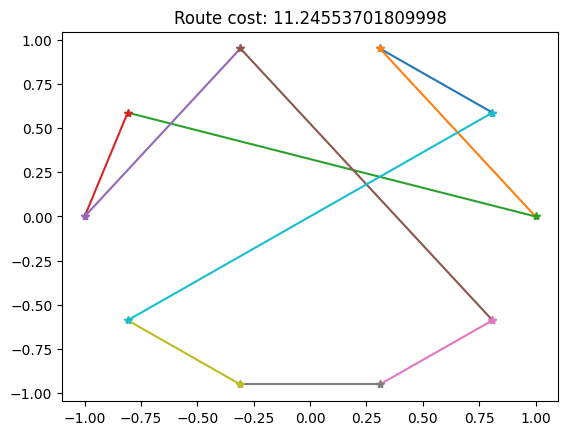

In [125]:
# generate n points on a plane 
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2)
n = 10
degs = np.linspace(0, 2*np.pi, n, endpoint=False)
#points = np.array([[np.cos(d)+np.random.random(1), np.sin(d)+np.random.random(1)] for d in degs])
points = np.array([[np.cos(d), np.sin(d)] for d in degs])

def cost_func(points, order_array):
    c = 0
    order_array = np.array(order_array)-1
    for i in range(1,len(order_array)):

        c += np.linalg.norm(points[order_array[i-1]]-points[order_array[i]])

    # last point
    c += np.linalg.norm(points[order_array[0]]-points[order_array[-1]])

    return c

fade = np.linspace(0.01,1,n)
current_route = np.array([2,3,1,5,6,4,10,9,8,7])
plt.title(f"Route cost: {cost_func(points, current_route)}")


route_idx = current_route - 1

for i in range(1, len(route_idx)):
    plt.plot(
        [points[route_idx[i-1], 0], points[route_idx[i], 0]],
        [points[route_idx[i-1], 1], points[route_idx[i], 1]],
        '*-'
    )

plt.plot(
    [points[route_idx[-1], 0], points[route_idx[0], 0]],
    [points[route_idx[-1], 1], points[route_idx[0], 1]],
    '*-'
)

In [126]:
# generate proposal by swapping two randomly selected points on the route 

# def generate_proposal(order_array):
#     new_route = order_array.copy()
#     # randomly swap two elements
#     indexes = np.array(list(range(0,n-1)))
#     #np.random.seed(2)
#     random1 = int(np.random.choice(indexes))
#     #np.random.seed(42)
#     random2 = int(np.random.choice(indexes))

#     new_route[random1] = order_array[random2]
#     new_route[random2] = order_array[random1]
#     return new_route
def generate_proposal(order_array):
    new_route = order_array.copy()
    i, j = np.random.choice(len(order_array), size=2, replace=False)
    new_route[i], new_route[j] = new_route[j], new_route[i]
    return new_route


route2 = generate_proposal(current_route)

print(current_route, f'cost {cost_func(points, current_route)}')
print(route2, f'cost {cost_func(points, route2)}')

[ 2  3  1  5  6  4 10  9  8  7] cost 11.24553701809998
[ 2  6  1  5  3  4 10  9  8  7] cost 13.354045557355448


In [127]:
def plot_route(points, route):
    plt.title(f"Initial route cost: {cost_func(points, route)}")


    route_idx = route - 1

    for i in range(1, len(route_idx)):
        plt.plot(
            [points[route_idx[i-1], 0], points[route_idx[i], 0]],
            [points[route_idx[i-1], 1], points[route_idx[i], 1]],
            '*-'
        )

    plt.plot(
        [points[route_idx[-1], 0], points[route_idx[0], 0]],
        [points[route_idx[-1], 1], points[route_idx[0], 1]],
        '*-'
    )

optimal route [ 6  5  4  3  2  1 10  9  8  7]


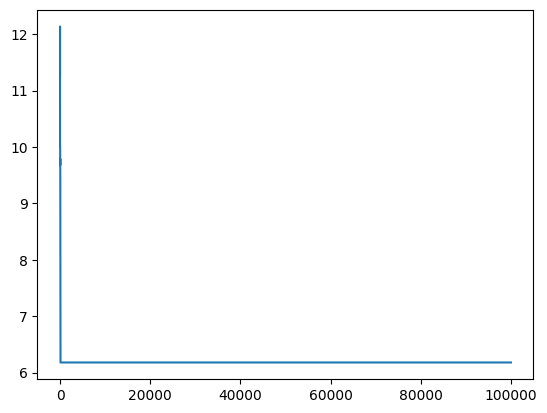

In [131]:
def cooling(k):
    return 1/(np.sqrt(1+k))

np.random.seed(42)
def run_traveling_salesman(points,initial_route,converge_threshold = 1e-6, max_rounds = 100_000):

    current_route = initial_route
    all_costs = []
    current_cost = cost_func(points,current_route)
    for k in range(max_rounds):
        all_costs.append(current_cost)
        proposal_route = generate_proposal(current_route)
        current_cost = cost_func(points,current_route)
        proposal_cost = cost_func(points,proposal_route)
        T = cooling(k) *0.5
        alpha = min(1,np.exp(-(proposal_cost-current_cost)/T))

        # acceptance
        if np.random.rand(1) <=alpha:
            current_route = proposal_route

        if (np.abs(current_cost-proposal_cost) <= converge_threshold) and k>1000:
            current_cost = cost_func(points,current_route)
            print(f'hit convergence at k={k} with cost = {current_cost}')
            return current_route, all_costs
    return current_route, all_costs


current_route = np.array([2,3,1,5,6,4,10,9,8,7])

optimal_route, all_costs = run_traveling_salesman(points,current_route)
print('optimal route',optimal_route)
plt.plot(list(range(0,len(all_costs))), all_costs)


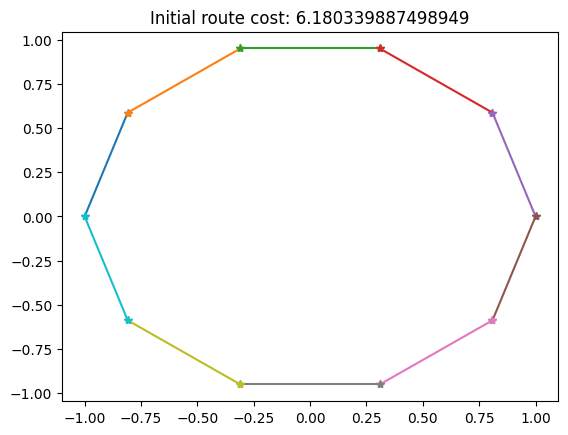

In [132]:
plot_route(points, optimal_route)

## part 2

In [137]:
import pandas as pd

costs = pd.read_csv('cost.csv', header=None)
costs = np.array(costs)
costs.shape

(20, 20)

first route [ 1 18 16  2  9  6 12  4 19 17 14  3 10 20  5 13  8 11 15  7]
optimal route [ 7 17 11 20  3  1 13  4 12  6 14  9  2  8  5 19 15 10 16 18] with optimal cost  942



/var/folders/mk/0w5j6hcs1js4172_jsztz29w0000gn/T/ipykernel_82545/71199946.py:32: RuntimeWarning: overflow encountered in exp
  alpha = min(1,np.exp(-(proposal_cost-current_cost)/T))


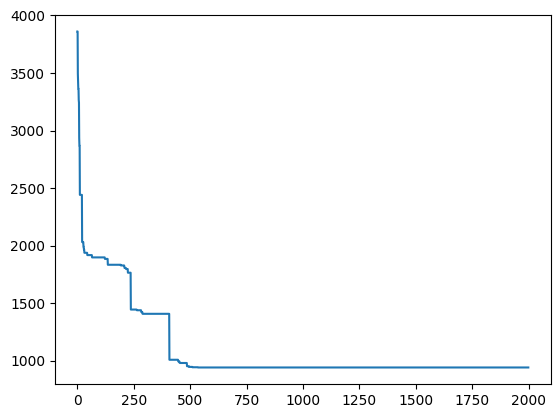

In [160]:
n = 20
np.random.seed(42)
first_route = np.random.choice(list(range(1,n+1)), size=n, replace=False)
print(f'first route {first_route}')
degs = np.linspace(0, 2*np.pi, n, endpoint=False)
#points = np.array([[np.cos(d)+np.random.random(1), np.sin(d)+np.random.random(1)] for d in degs])
points = np.array([[np.cos(d), np.sin(d)] for d in degs])

def cost_func_altered(points, order_array):
    c = 0
    order_array = np.array(order_array)-1
    for i in range(1,len(order_array)):
        c += costs[order_array[i-1],order_array[i]]

    # last point
    c += costs[order_array[0],order_array[-1]]

    return c


def run_traveling_salesman_altered(points,initial_route,converge_threshold = 1e-6, max_rounds = 100_000):

    current_route = initial_route
    all_costs = []
    current_cost = cost_func_altered(points,current_route)
    for k in range(max_rounds):
        all_costs.append(current_cost)
        proposal_route = generate_proposal(current_route)
        current_cost = cost_func_altered(points,current_route)
        proposal_cost = cost_func_altered(points,proposal_route)
        T = cooling(k) 
        alpha = min(1,np.exp(-(proposal_cost-current_cost)/T))

        # acceptance
        if np.random.rand(1) <=alpha:
            current_route = proposal_route

        if (np.abs(current_cost-proposal_cost) <= converge_threshold) and k>1000:
            current_cost = cost_func_altered(points,current_route)
            print(f'hit convergence at k={k} with cost = {current_cost}')
            return current_route, all_costs
    return current_route, all_costs


best_route, all_costs = run_traveling_salesman_altered(points,first_route,max_rounds=2_000 )
print('optimal route',best_route, 'with optimal cost ',cost_func_altered(points,best_route))
plt.plot(list(range(0,len(all_costs))), all_costs)
print()
